# Data Exploration

## Imports

In [ ]:
!pip install pandas numpy matplotlib seaborn scipy nltk textblob

import os
import warnings

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import skew

# Text analysis
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
from textblob import TextBlob

# Configure plots to be inline
%matplotlib inline

### Notebook settings

In [13]:
warnings.filterwarnings("ignore")

## Loading Data

### Initializing dataframes

In [6]:
dataset_dir = 'dataset/'

player_handle_csv_file = f'{dataset_dir}player_handle.csv'
player_stat_csv_file = f'{dataset_dir}player_stat.csv'
player_tweet_csv_file = f'{dataset_dir}player_tweet.csv'

player_handle_df = pd.read_csv(player_handle_csv_file)
player_stat_df = pd.read_csv(player_stat_csv_file)
player_tweet_df = pd.read_csv(player_tweet_csv_file)

final_player_stat_csv_file = f'{dataset_dir}final_player_stat.csv'
final_player_tweet_csv_file = f'{dataset_dir}final_player_tweet.csv'

final_player_stat_tweet_csv_file = f'{dataset_dir}final_player_stat_tweet.csv'

C:\Users\coleb\AppData\Local\Temp\ipykernel_10408\653939393.py:8: DtypeWarning: Columns (1,12,17,21,25,26,28,29,32,33,35,37,40,44,46,50,51,53,56,59,60,62,64,69,75,76,77,78,81,83,84,86,88,89,96,103,105,106,111,115,116,117,121) have mixed types. Specify dtype option on import or set low_memory=False.
  player_stat_df = pd.read_csv(player_stat_csv_file)


### Checkpoints

In [7]:
# Check if the files exist before reading
if os.path.exists(final_player_tweet_csv_file):
    player_tweet_df = pd.read_csv(final_player_tweet_csv_file)

if os.path.exists(final_player_stat_csv_file):
    player_stat_df = pd.read_csv(final_player_stat_csv_file)

if os.path.exists(final_player_stat_tweet_csv_file):
    player_stat_tweet_df = pd.read_csv(final_player_stat_tweet_csv_file)

## Transformations

### Filter by Correct Years

In [19]:
# Convert the 'Date' column to datetime format
player_stat_df['Date'] = pd.to_datetime(player_stat_df['Date'], errors='coerce')

# Define the cutoff date to be the 2006 NFL season and onwards
cutoff_date = pd.Timestamp('2006-03-01')

# Filter the DataFrame
player_stat_df = player_stat_df[player_stat_df['Date'] > cutoff_date]

C:\Users\coleb\AppData\Local\Temp\ipykernel_24604\1075847195.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  player_stat_df['Date'] = pd.to_datetime(player_stat_df['Date'], errors='coerce')


### Filter to only NFL games

In [20]:
# Filter the DataFrame
player_stat_df = player_stat_df[player_stat_df['Lg'] == 'NFL']

### Replace "--" values with 0

In [21]:
# Replace '--' with 0 in all columns except 'Date'
columns_to_replace = player_stat_df.columns.difference(['Date'])  # Exclude the 'Date' column
player_stat_df[columns_to_replace] = player_stat_df[columns_to_replace].replace('--', 0)

# Convert numeric columns to appropriate types after replacement
player_stat_df[columns_to_replace] = player_stat_df[columns_to_replace].apply(pd.to_numeric, errors='ignore')

### Convert Ratios (e.g. for field goal kicking) into floats

In [22]:
# Define a function to convert "X-Y" strings into X / Y
def convert_dash_to_float(value):
    if isinstance(value, str) and '-' in value:
        try:
            # Split the string into two parts and convert to integers
            x, y = map(int, value.split('-'))
            return x / y if y != 0 else np.nan  # Avoid division by zero
        except ValueError:
            return value  # Return the value unchanged if it's not valid
    return value

# Define a function to convert "X/Y" strings into X / Y
def convert_slash_to_float(value):
    if isinstance(value, str):
        if value == '/':  # Handle the special case where the value is just '/'
            return 0
        if '/' in value:
            try:
                # Split the string into two parts and convert to integers
                x, y = map(int, value.split('/'))
                return x / y if y != 0 else np.nan  # Avoid division by zero
            except ValueError:
                return value  # Return the value unchanged if it's not valid
    return value

# Apply the function to all columns except 'Date'
columns_to_convert = player_stat_df.columns.difference(['Date'])
player_stat_df[columns_to_convert] = player_stat_df[columns_to_convert].applymap(convert_dash_to_float)

slash_columns_to_convert = ['Kicking_PAT', 'Kicking_FG']
player_stat_df[slash_columns_to_convert] = player_stat_df[slash_columns_to_convert].applymap(convert_slash_to_float)

# Convert numeric columns to appropriate types after replacement
player_stat_df[slash_columns_to_convert] = player_stat_df[slash_columns_to_convert].apply(pd.to_numeric, errors='ignore')

### Remove trailing 't' from Lg stats

In [23]:
# Define the columns to clean (or target all non-numeric columns)
columns_to_clean = ['Punt Returns_Lg', 'Kickoff Returns_Lg', 'Interceptions_Lg', 'Receiving_Lg', 'Passing_Lg', 'Rushing_Lg']

# Remove trailing 't' characters from all values in the specified columns
player_stat_df[columns_to_clean] = player_stat_df[columns_to_clean].replace(r'(\d+)t$', r'\1', regex=True)

# Optionally, convert the cleaned columns to numeric where applicable
player_stat_df[columns_to_clean] = player_stat_df[columns_to_clean].apply(pd.to_numeric, errors='ignore')

### Ensure all non-numeric columns are expected

In [24]:
# Get non-numeric columns
non_numeric_columns = player_stat_df.select_dtypes(exclude='number')

# Print the names of the non-numeric columns
print("Non-numeric column names:", non_numeric_columns.columns.tolist())

Non-numeric column names: ['Res', 'Lg', 'Date', 'Opp', 'Team', 'Player_Name']


### Group Stats by Game

In [25]:
# Grouping by Player_Name, Res, Lg, Date, Opp, and Team
grouped_player_stat_df = player_stat_df.groupby(['Player_Name', 'Res', 'Lg', 'Date', 'Opp', 'Team'])

# Define a lambda function to calculate mean or keep NaN if all values are NaN
aggregate_function = lambda x: x.mean() if not x.isna().all() else float('nan')

# Apply the lambda function to all columns
player_stat_df = grouped_player_stat_df.agg({col: aggregate_function for col in player_stat_df.columns if col not in ['Player_Name', 'Res', 'Lg', 'Date', 'Opp', 'Team']}).reset_index()

### Save to csv

In [26]:
# Save the dataframe back to the CSV file
player_stat_df.to_csv(final_player_stat_csv_file, index=False)

## Create Player Performance Features

### Positive/negative feature split

In [28]:
positive_columns = [
    "Misc_PD",
    "Kickoffs_Lg",
    "Extra Points_Pct",
    "Passing_Att",
    "Kickoff Returns_Yds",
    "Receiving_Tar",
    "Punt Returns_Yds",
    "Field Goals_Lg",
    "Punt Returns_Lg",
    "Receiving_Rec",
    "Kickoff Returns_Num",
    "Touchdowns_P",
    "Punt Returns_Avg",
    "Rushing_TD",
    "Passing_Cmp",
    "Recoveries_Own",
    "Interceptions_TD",
    "Punts_Lg",
    "Touchdowns_IR",
    "Kickoffs_TB",
    "Kickoffs_TBLZ",
    "Punt Returns_Num",
    "Kickoff Returns_TD",
    "Field Goals_50+",
    "Punt Returns_FC",
    "Punts_Yds",
    "Field Goals_20-29",
    "Sacks_Sack",
    "Kickoff Returns_Lg",
    "Rushing_Gain",
    "Rushing_Att",
    "Kickoff Returns_FC",
    "Field Goals_FGA",
    "Passing_Pct",
    "Passing_YPA",
    "Touchdowns_R",
    "Tackles_Ast",
    "Kickoffs_Avg",
    "Misc_QBH",
    "Field Goals_FGM",
    "Rushing_Avg", 
    "Punts_50+", 
    "Punts_Avg", 
    "Passing_Yds", 
    "Field Goals_0-19", 
    "Kickoffs_Yds", 
    "Returns_Yds", 
    "Rushing_FD", 
    "Touchdowns_PR", 
    "Passing_Rate", 
    "Punts_In20", 
    "Extra Points_XPA", 
    "Returns_TD", 
    "Kicking_PAT", 
    "Field Goals_30-39", 
    "Field Goals_40-49", 
    "Receiving_20+", 
    "Pts", 
    "Receiving_FD", 
    "Receiving_TD", 
    "Rushing_Yds", 
    "Kickoffs_Num", 
    "Interceptions_Lg", 
    "Punts_Dwn", 
    "Field Goals_Pct", 
    "Recoveries_Tot", 
    "Passing_FD", 
    "Touchdowns_KR", 
    "Tackles_Solo", 
    "Receiving_Avg", 
    "Kickoff Returns_Avg", 
    "Touchdowns_Tot", 
    "Receiving_YAC", 
    "Extra Points_XPM", 
    "Receiving_Yds", 
    "Passing_TD%T%", 
    "Passing_TD", 
    "Kicking_FG", 
    "Receiving_Lg", 
    "Passing_Lg", 
    "Interceptions_Yds", 
    "Rushing_Lg", 
    "Touchdowns_FR", 
    "Kickoffs_In20", 
    "Rushing_10+", 
    "Misc_Conv",
    "Punts_Net",
    "Passing_20+",
    "Tackles_Tot",
    "Misc_Saf",
    "Punts_Num",
    "Punts_OB",
    "Punt Returns_TD",
    "Interceptions_Int", 
    "Fumbles_Forced",
    "Onside Kicks_OSR",
    "Onside Kicks_OSK",
    "Punts_FC", 
    "Sacks_YdsL",
    "Interceptions_Avg",
    "Misc_Pts",
]

negative_columns = [
    "Punts_Blk",
    "Passing_Sack",
    "Passing_Loss",
    "Opponent Returns_RYds",
    "Opp. Returns_TD",
    "Kickoffs_OB",
    "Opponent Returns_Ret",
    "Passing_Int",
    "Opponent Returns_TD",
    "Fumbles_Fum", 
    "Rushing_Loss", 
    "Opp. Returns_Ret", 
    "Fumbles_Lost", 
    "Punts_TB",  
    "Passing_Int%I%",
    "Opp. Returns_RYds",
    "Recoveries_Opp",
    "Kickoffs_Short"
]

### Player-relative performance

In [29]:
# Make a copy of the original DataFrame
player_relative_stat_df = player_stat_df.copy()

# Fill missing values with 0 for the specified columns
player_relative_stat_df[positive_columns + negative_columns] = player_relative_stat_df[positive_columns + negative_columns].fillna(0)

# Calculate per-row performance scores
player_relative_stat_df['Positive_Score'] = player_relative_stat_df[positive_columns].sum(axis=1)
player_relative_stat_df['Negative_Score'] = player_relative_stat_df[negative_columns].sum(axis=1)
player_relative_stat_df['Total_Score'] = player_relative_stat_df['Positive_Score'] - player_relative_stat_df['Negative_Score']

# For each player, find their min and max Total_Score
player_min = player_relative_stat_df.groupby('Player_Name')['Total_Score'].transform('min')
player_max = player_relative_stat_df.groupby('Player_Name')['Total_Score'].transform('max')

# Normalize each player's performance relative to their own historical range
player_relative_stat_df['Player_Relative_Performance'] = (player_relative_stat_df['Total_Score'] - player_min) / (player_max - player_min)

# If there are cases where a player has the same score for all games (max == min),
# you might end up dividing by zero. Handle that case by assigning a default value:
player_relative_stat_df['Player_Relative_Performance'] = player_relative_stat_df['Player_Relative_Performance'].fillna(0.5)

# Update the original DataFrame
player_stat_df = player_relative_stat_df.copy()

C:\Users\coleb\AppData\Local\Temp\ipykernel_24604\3353088432.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  player_relative_stat_df['Positive_Score'] = player_relative_stat_df[positive_columns].sum(axis=1)
C:\Users\coleb\AppData\Local\Temp\ipykernel_24604\3353088432.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  player_relative_stat_df['Negative_Score'] = player_relative_stat_df[negative_columns].sum(axis=1)
C:\Users\coleb\AppData\Local\Temp\ipykernel_24604\3353088432.py:10: PerformanceWarning: DataFrame is highly frag

### Save to csv

In [30]:
# Save the dataframe back to the CSV file
player_stat_df.to_csv(final_player_stat_csv_file, index=False)

## Create Tweet Sentiment Features

### Positive, neutral, and negative classification (VADER rule-based lexicon)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\coleb\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


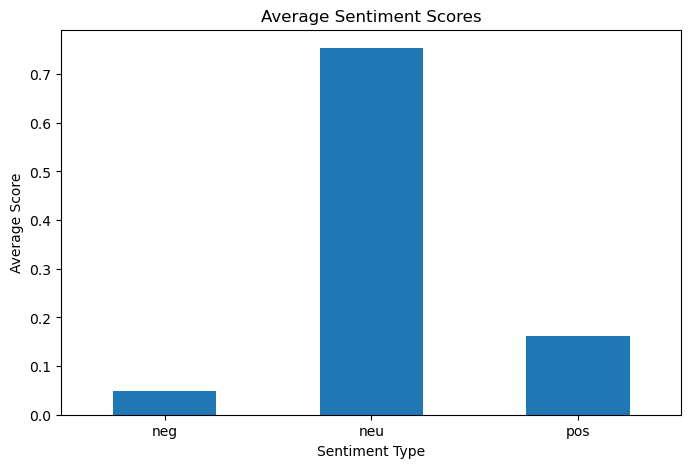

In [32]:
# Download necessary NLTK data
nltk.download('vader_lexicon')

# Initialize the sentiment analyzer
sia = SentimentIntensityAnalyzer()

# Replace non-string or NaN values in 'text' column with an empty string
player_tweet_df['text'] = player_tweet_df['text'].fillna('').astype(str)

# Add sentiment analysis columns
player_tweet_df[['neg', 'neu', 'pos', 'compound']] = player_tweet_df['text'].apply(
    lambda text: pd.Series(sia.polarity_scores(text))
)

# Group sentiment scores for visualization
sentiment_counts = player_tweet_df[['neg', 'neu', 'pos']].mean()

# Plot sentiment distribution
plt.figure(figsize=(8, 5))
sentiment_counts.plot(kind='bar', title='Average Sentiment Scores')
plt.xlabel('Sentiment Type')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.show()

### Polarity and subjectivity (TextBlob)

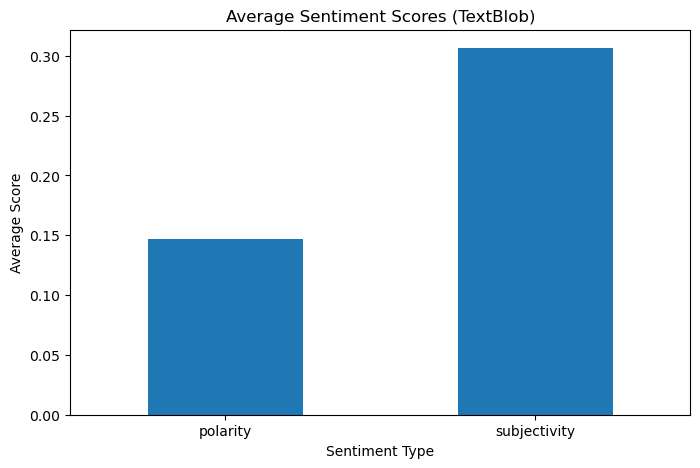

In [33]:
# Replace non-string or NaN values in 'text' column with an empty string
player_tweet_df['text'] = player_tweet_df['text'].fillna('').astype(str)

# Function to get sentiment scores from TextBlob
def get_textblob_sentiment(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity  # Polarity score ranges from -1 (negative) to 1 (positive)
    subjectivity = blob.sentiment.subjectivity  # Subjectivity score ranges from 0 (objective) to 1 (subjective)
    return pd.Series([polarity, subjectivity])

# Add sentiment analysis columns
player_tweet_df[['polarity', 'subjectivity']] = player_tweet_df['text'].apply(get_textblob_sentiment)

# Group sentiment polarity for visualization
average_sentiment = player_tweet_df[['polarity', 'subjectivity']].mean()

# Plot sentiment distribution
plt.figure(figsize=(8, 5))
average_sentiment.plot(kind='bar', title='Average Sentiment Scores (TextBlob)')
plt.xlabel('Sentiment Type')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.show()


### Save to csv

In [34]:
# Save the dataframe back to the CSV file
player_tweet_df.to_csv(final_player_tweet_csv_file, index=False)

## Combining Datasets

### Creating relationship between player performance and tweets

In [36]:
# Convert date columns to datetime
player_stat_df['Date'] = pd.to_datetime(player_stat_df['Date'])
player_tweet_df['date'] = pd.to_datetime(player_tweet_df['date'])

# Merge player_stat with player_handle to get twitter_username
# Assuming "Player_Name" in player_stat matches "player_name" in player_handle
merged_stats = pd.merge(player_stat_df, player_handle_df, how='inner', 
                        left_on='Player_Name', right_on='player_name')

# Merge tweets with merged_stats on twitter_username
# We'll do an inner merge on twitter_username
merged = pd.merge(merged_stats, player_tweet_df, how='inner', 
                  left_on='twitter_profile', right_on='player_handle')

# Ensure both columns are timezone-naive
merged['Date'] = merged['Date'].dt.tz_localize(None)
merged['date'] = merged['date'].dt.tz_localize(None)

# Now filter so that only tweets from the previous 30 days are included
# Condition: Game_Date - Tweet_Date >= 0 and <= 30 days
merged['Days_Before_Game'] = (merged['Date'] - merged['date']).dt.days

# Keep only rows where Days_Before_Game is between 0 and 30 (inclusive)
filtered = merged[(merged['Days_Before_Game'] >= 0) & (merged['Days_Before_Game'] <= 30)]

# Select the columns you want to keep.
# The final table should include columns from player_stat, plus is_repost,neg,neu,pos,compound,polarity,subjectivity from tweets
final_columns = ['Player_Name', 'Date', 'Player_Relative_Performance'] + [
    'is_repost','neg','neu','pos','compound','polarity','subjectivity','Days_Before_Game'
]
# Ensure these columns exist in filtered
final_columns = [col for col in final_columns if col in filtered.columns]

player_stat_tweet_df = filtered[final_columns].copy()

# final now contains the joined table grouped by each player game with associated tweets
# If you want to group or sort the final result, you can do so here.
# For example, sorting by Player_Name, Date, Days_Before_Game:
player_stat_tweet_df.sort_values(by=['Player_Name', 'Date', 'Days_Before_Game'], inplace=True)

# Write out or use final as needed
player_stat_tweet_df.to_csv(final_player_stat_tweet_csv_file, index=False)

### Save to csv

In [37]:
# Save the dataframe back to the CSV file
player_stat_tweet_df.to_csv(final_player_stat_tweet_csv_file, index=False)

## Feature Identification

In [49]:
# Convert the Date column to datetime
player_stat_tweet_df['Date'] = pd.to_datetime(player_stat_tweet_df['Date'])

# Separate numerical and categorical features
# Note: After conversion, 'Date' is no longer object type. Let's assume we still consider it separately.
numerical_features = player_stat_tweet_df.select_dtypes(include=["float64", "int64"]).columns.tolist()
boolean_features = player_stat_tweet_df.select_dtypes(include=["bool"]).columns.tolist()

# For categorical, let's consider strings and possibly datetime as a separate case:
object_like_features = player_stat_tweet_df.select_dtypes(include=["object"]).columns.tolist()
datetime_features = player_stat_tweet_df.select_dtypes(include=["datetime"]).columns.tolist()

# Get ranges for numerical features
numerical_ranges = {col: (player_stat_tweet_df[col].min(), player_stat_tweet_df[col].max()) for col in numerical_features}

# For datetime features, show a date range
datetime_ranges = {col: (player_stat_tweet_df[col].min(), player_stat_tweet_df[col].max()) for col in datetime_features}

# For object/boolean features (categorical), show unique values
categorical_values = {col: player_stat_tweet_df[col].unique().tolist() for col in object_like_features + boolean_features}

# Display the results
print("Numerical Features and Ranges:")
for col, range_ in numerical_ranges.items():
    print(f"{col}: Min = {range_[0]}, Max = {range_[1]}")

print("\nDatetime Features and Ranges:")
for col, range_ in datetime_ranges.items():
    print(f"{col}: From {range_[0].date()} to {range_[1].date()}")

print("\nCategorical Features and Values:")
for col, values in categorical_values.items():
    if len(values) > 2:
        print(f"{col} Count: {len(values)}")
    else:
        print(f"{col}: {values}")

Numerical Features and Ranges:
Player_Relative_Performance: Min = 0.0, Max = 1.0
neg: Min = 0.0, Max = 1.0
neu: Min = 0.0, Max = 1.0
pos: Min = 0.0, Max = 1.0
compound: Min = -0.9756, Max = 0.9892
polarity: Min = -1.0, Max = 1.0
subjectivity: Min = 0.0, Max = 1.0
Days_Before_Game: Min = 0.0, Max = 30.0

Datetime Features and Ranges:
Date: From 2011-09-11 to 2024-12-01

Categorical Features and Values:
Player_Name Count: 67
is_repost: [True, False]


## Seaborn single feature plots

### Histogram of subjectivity

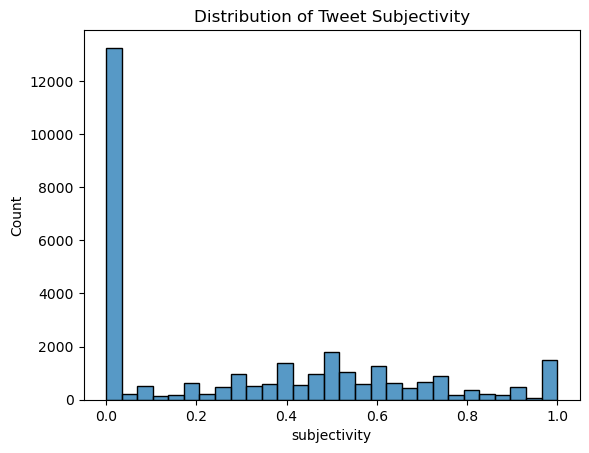

In [50]:
sns.histplot(player_tweet_df, x='subjectivity')
plt.title('Distribution of Tweet Subjectivity')
plt.show()

Explanation

There seems to be a slight bell curve besides the extremes. This indicates the existence of outliers that could potentially be removed for more accurate modeling.

### Kernel Density Estimate (KDE) Plot of Player_Relative_Performance

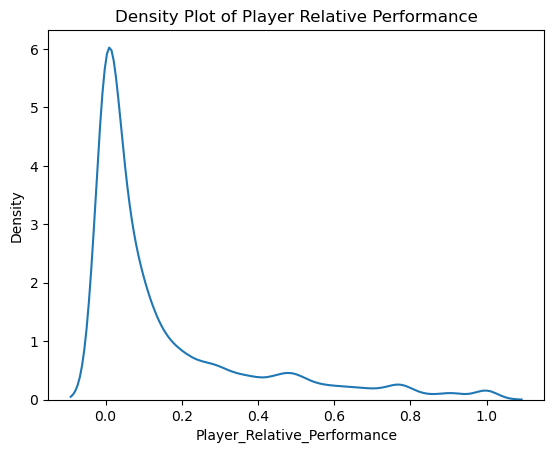

In [51]:
sns.kdeplot(player_stat_df['Player_Relative_Performance'].dropna())
plt.title('Density Plot of Player Relative Performance')
plt.show()

Explanation

Players seem to generally perform signficantly worse than their peak. Also might indicate outliers where players didn't play.

### Count Plot of Days_Before_Game

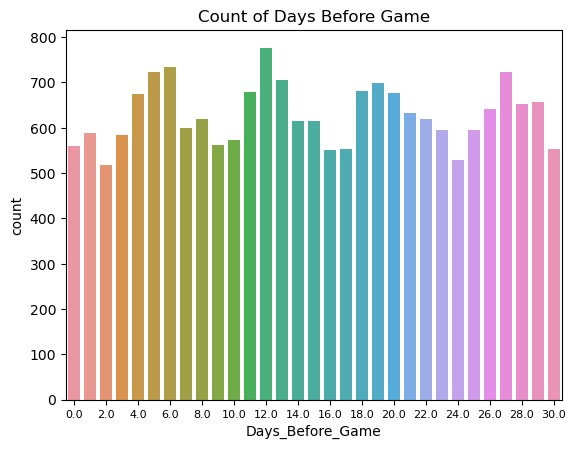

In [55]:
sns.countplot(data=player_stat_tweet_df, x='Days_Before_Game')
plt.title('Count of Days Before Game')

# Get the current tick locations and labels
ticks = plt.xticks()[0]  # Get the positions of the ticks
labels = plt.xticks()[1]  # Get the labels of the ticks

# Set ticks and labels, skipping every other tick
plt.xticks(ticks=ticks[::2], labels=[label.get_text() for label in labels[::2]], fontsize=8)

plt.show()

Explanation

Players seem to tweet most often the day after their games (days = multiples of 7 - 1). 

Although there might exist a relationship between further occuring tweets, we might consider tranforming the feature to be exponential or logarithmic across its range so that the further a tweet occured from a game, it becomes exponentially less meaningful or logarithmically less meaningful.

### Box Plot of compound

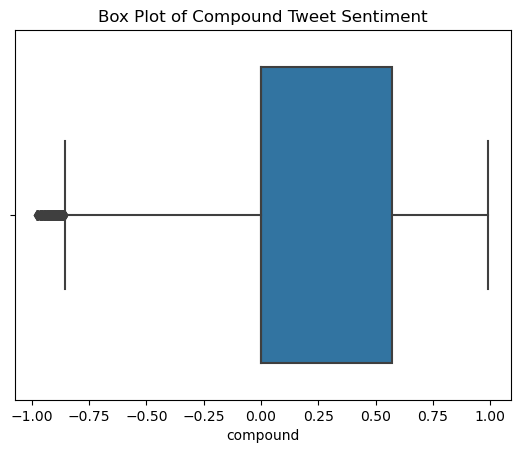

In [62]:
sns.boxplot(data=player_tweet_df, x='compound')
plt.title('Box Plot of Compound Tweet Sentiment')
plt.show()

#### Explanation

The vast majority of tweets are mostly positive (indicated by the range of 0.0-0.6).

### Violin Plot of Date

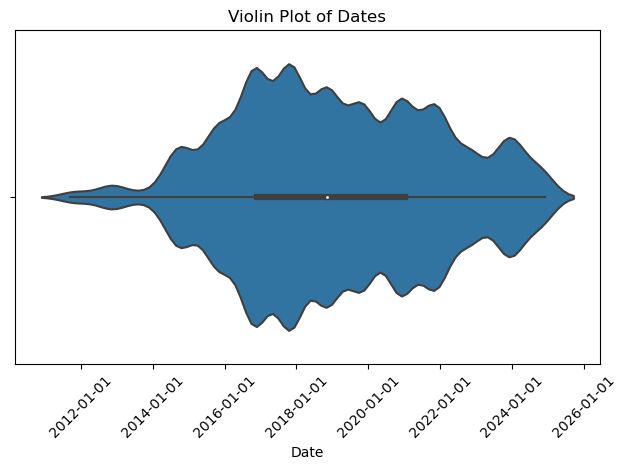

In [ ]:
# Convert the Date column to numeric values
player_stat_tweet_df['Date_numeric'] = mdates.date2num(player_stat_tweet_df['Date'])

# Create a violin plot
sns.violinplot(data=player_stat_tweet_df, x='Date_numeric')
plt.title('Violin Plot of Dates')
plt.xlabel('Date')

# Format the x-axis to show dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Explanation

Most tweet-game matches for our dataset occurred from 2016-2022. 

Date's might be a signficant factor for how social media has evolved in the NFL and how players attitudes towards it have changed. Including date (as numeric) might be useful for modeling.

## Two feature plots in seaborn

### Scatter Plot of VADER vs TextBlob Tweet Sentiment with Subjectivity

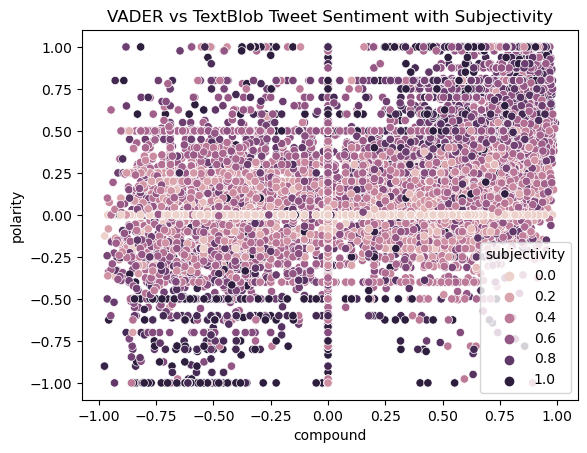

In [26]:
# Explanation: This scatter plot visualizes the relationship between passing yards and rushing yards, with points colored by game result. It helps identify any correlation between the two variables and how they relate to winning or losing games.
sns.scatterplot(data=player_tweet_df, x='compound', y='polarity', hue='subjectivity')
plt.title('VADER vs TextBlob Tweet Sentiment with Subjectivity')
plt.show()

#### Explanation

VADER Compound and TextBlob Polarity are meant to provide analysis on similiar measurements. If they matched exactly, they would line up perfectly in a linear fashion (graph that looks like y = x). Their differences are most likely signficant and using both in conjunction with each other is probably necessary.

It can also be seen that outliers (negative correlation or y = -x) tend to be highly subjective.

### Swarm Plot of Player Relative Performance by Polarity for Very Recent Tweets

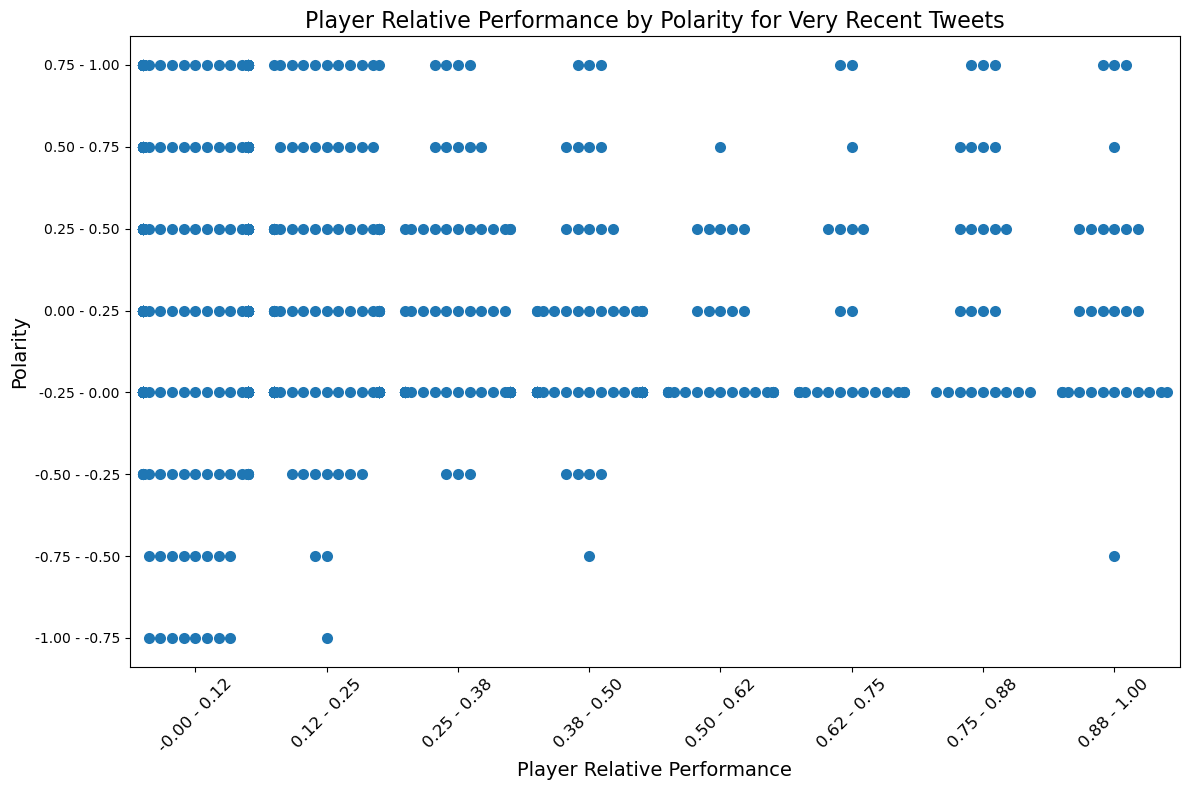

In [18]:
# Filter the DataFrame
filtered_df = player_stat_tweet_df[
    (player_stat_tweet_df['Days_Before_Game'] <= 1)
]

# Bin the 'Player_Relative_Performance' into 8 bins
performance_bins = pd.cut(filtered_df['Player_Relative_Performance'], bins=8)
polarity_bins = pd.cut(filtered_df['polarity'], bins=8)

# Extract categories for creating labels
performance_bin_labels = [f"{bin.left:.2f} - {bin.right:.2f}" for bin in performance_bins.cat.categories]
polarity_bin_labels = [f"{bin.left:.2f} - {bin.right:.2f}" for bin in polarity_bins.cat.categories]

# Map bins back to their labeled categories for plotting
filtered_df['Performance_Bins'] = pd.cut(
    filtered_df['Player_Relative_Performance'], 
    bins=8,
    labels=performance_bin_labels
)
filtered_df['Polarity_Bins'] = pd.cut(
    filtered_df['polarity'], 
    bins=8,
    labels=polarity_bin_labels
)

# Create the swarm plot with sorted bins
plt.figure(figsize=(12, 8))
sns.swarmplot(
    x='Performance_Bins',
    y='Polarity_Bins',
    data=filtered_df,
    order=performance_bin_labels,  # Ensure sorted order for x-axis
    hue_order=None,  # Ensure sorted order for y-axis
    size=8
)

# Manually set the y-axis order to ascending
plt.gca().invert_yaxis()

# Customize the plot
plt.title('Player Relative Performance by Polarity for Very Recent Tweets', fontsize=16)
plt.xlabel('Player Relative Performance', fontsize=14)
plt.ylabel('Polarity', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.tight_layout()

# Show the plot
plt.show()


#### Explanation

For very recent tweets (0-1 days before) associated with high performance games, players usually don't tweet negatively.

### Strip Plot of Player Relative Performance associated with Negative Tweets on Different Days

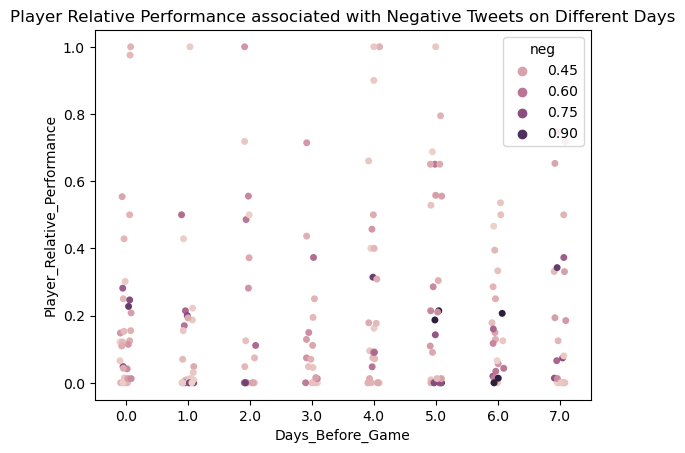

In [32]:
# Filter the DataFrame
filtered_df = player_stat_tweet_df[
    (player_stat_tweet_df['Days_Before_Game'] <= 7) &
    (player_stat_tweet_df['neg'] >= 0.3)
]

sns.stripplot(data=filtered_df, x='Days_Before_Game', y='Player_Relative_Performance', jitter=True, hue='neg')
plt.title('Player Relative Performance associated with Negative Tweets on Different Days')
plt.show()

#### Explanation

A few insights can be seen from this visualization:
- Players who tweet negatively 5 days before the game tend to have better performances
- All of the very negative tweets (neg = 0.9) occur 5 or 6 days before a game
    - These might be associated with the aftermath of the previous game (possibly trash talking after beating an opponent) and might indicate that a player or team is doing well for the entire season
- There aren't many negative tweets 1-3 days before a game, and the players that do tweet negatively during this period don't perform as well

## Exploratory data analysis

### Understand the Data

In [34]:
# Size of the Dataset:
print(player_stat_tweet_df.shape)

(19485, 11)


### Identify Relationships Between Features

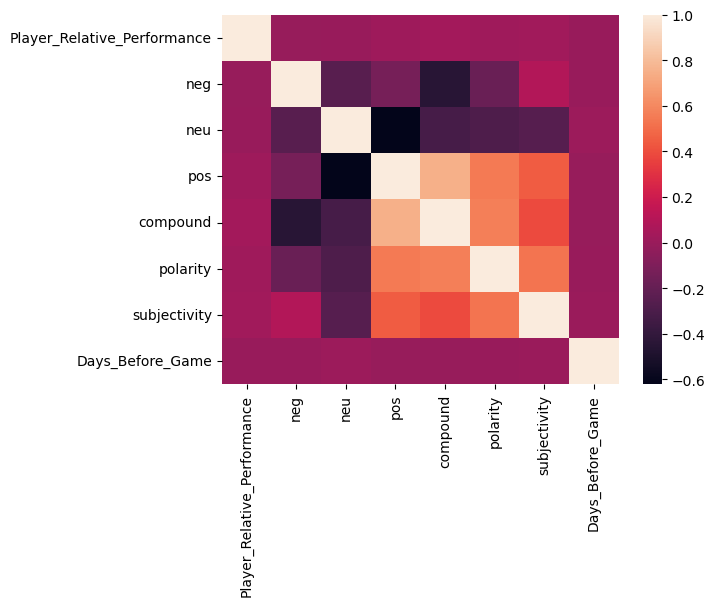

In [37]:
numerical_cols = player_stat_tweet_df.select_dtypes(include=['float64', 'int64']).columns
correlation = player_stat_tweet_df[numerical_cols].corr()
sns.heatmap(correlation)
plt.show()

#### Explanation

Player Relative Performance doesn't correlate directly with any of the tweet analysis metrics.

### Describe the Shape of Data

In [40]:
# Identify numeric columns
numeric_columns = ['Player_Relative_Performance', 'neg', 'neu', 'pos', 'compound', 'polarity', 'subjectivity', 'Days_Before_Game']

# Calculate skewness
skewness_values = player_stat_tweet_df[numeric_columns].apply(skew)

# Print skewness values
print("Skewness of Numeric Columns:")
print(skewness_values)

Skewness of Numeric Columns:
Player_Relative_Performance    1.641067
neg                            4.039496
neu                           -1.095997
pos                            1.202776
compound                       0.004629
polarity                       0.747629
subjectivity                   0.678320
Days_Before_Game               0.010476
dtype: float64


#### Explanation

**Player_Relative_Performance (Skewness = 1.641067)**
- Positive Skew: The distribution is skewed to the right.
- Interpretation: Most performances are below the player's relative peak, with a few high values pulling the mean upward. This might indicate that players typically perform closer to their average or worst performance relative to their best.

**neg (Skewness = 4.039496)**
- Strong Positive Skew: A highly right-skewed distribution.
- Interpretation: Most tweets have low negative sentiment scores, but a few tweets have very high negative sentiment, pulling the distribution's tail to the right. This could indicate that strongly negative tweets are rare.

**neu (Skewness = -1.095997)**
- Negative Skew: The distribution is skewed to the left.
- Interpretation: Many tweets have high neutral sentiment scores, but a few tweets have significantly lower neutral scores, pulling the tail to the left. This indicates that highly neutral tweets dominate the data, with a few exceptions.

**pos (Skewness = 1.202776)**
- Positive Skew: The distribution is skewed to the right.
- Interpretation: Many tweets have low positive sentiment, but a few tweets with very high positive sentiment create a long right tail. Strongly positive tweets are less common.

**compound (Skewness = 0.004629)**
- Nearly Symmetric: Skewness close to 0 indicates a balanced distribution.
- Interpretation: The overall sentiment of tweets (accounting for positive, neutral, and negative components) is evenly distributed, with no significant bias toward extreme positive or negative sentiment.

**polarity (Skewness = 0.747629)**
- Moderate Positive Skew: The distribution is slightly skewed to the right.
- Interpretation: Tweets tend to have a slight bias toward neutral or slightly positive polarity, with a few tweets having strong positive polarity.

**subjectivity (Skewness = 0.678320)**
- Moderate Positive Skew: The distribution is slightly skewed to the right.
- Interpretation: Most tweets are more objective, but a few tweets are highly subjective, pulling the distribution's tail to the right. This might indicate that objective statements are more common in the dataset.

**Days_Before_Game (Skewness = 0.010476)**
- Nearly Symmetric: Skewness close to 0.
- Interpretation: The days before the game are distributed almost symmetrically, suggesting an even spread of tweets across this variable.

### Detect Outliers and Missing Data

**Missing Data:**

No data is missing, as all the relevant fields have been filtered to include only the correct data.

**Outliers:**

As previously discussed, the primary outliers and discrepancies within the data include: 
- Player Relative Performances of 0
- VADER compound vs TextBlob polarity
- Highly objective tweets
- Tweets associated with different games
- (Maybe) reposts

## Dataset Summary

### Shape of the Dataset

In [41]:
print(player_stat_tweet_df.shape)

(19485, 11)


### Information About the Dataset

In [42]:
player_stat_tweet_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19485 entries, 0 to 19484
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Player_Name                  19485 non-null  object 
 1   Date                         19485 non-null  object 
 2   Player_Relative_Performance  19485 non-null  float64
 3   is_repost                    19485 non-null  bool   
 4   neg                          19485 non-null  float64
 5   neu                          19485 non-null  float64
 6   pos                          19485 non-null  float64
 7   compound                     19485 non-null  float64
 8   polarity                     19485 non-null  float64
 9   subjectivity                 19485 non-null  float64
 10  Days_Before_Game             19485 non-null  float64
dtypes: bool(1), float64(8), object(2)
memory usage: 1.5+ MB


### Statistical Summary

In [43]:
player_stat_tweet_df.describe(include='all')

,Player_Name,Date,Player_Relative_Performance,is_repost,neg,neu,pos,compound,polarity,subjectivity,Days_Before_Game
count,19485,19485,19485.000000,19485,19485.000000,19485.000000,19485.000000,19485.000000,19485.000000,19485.000000,19485.000000
unique,67,607,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Mike Adams,2018-12-30,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1295,170,NaN,10093,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,0.177707,NaN,0.038195,0.749324,0.171987,0.241411,0.161205,0.292315,15.057737
std,NaN,NaN,0.228127,NaN,0.110079,0.272870,0.215999,0.391901,0.326225,0.324710,8.851329
min,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,-0.975600,-1.000000,0.000000,0.000000
25%,NaN,NaN,0.000000,NaN,0.000000,0.597000,0.000000,0.000000,0.000000,0.000000,7.000000
50%,NaN,NaN,0.074074,NaN,0.000000,0.803000,0.074000,0.000000,0.000000,0.200000,15.000000
75%,NaN,NaN,0.255243,NaN,0.000000,1.000000,0.300000,0.585900,0.312500,0.543750,23.000000


## Visualization Methods

### Histograms of Numerical Features

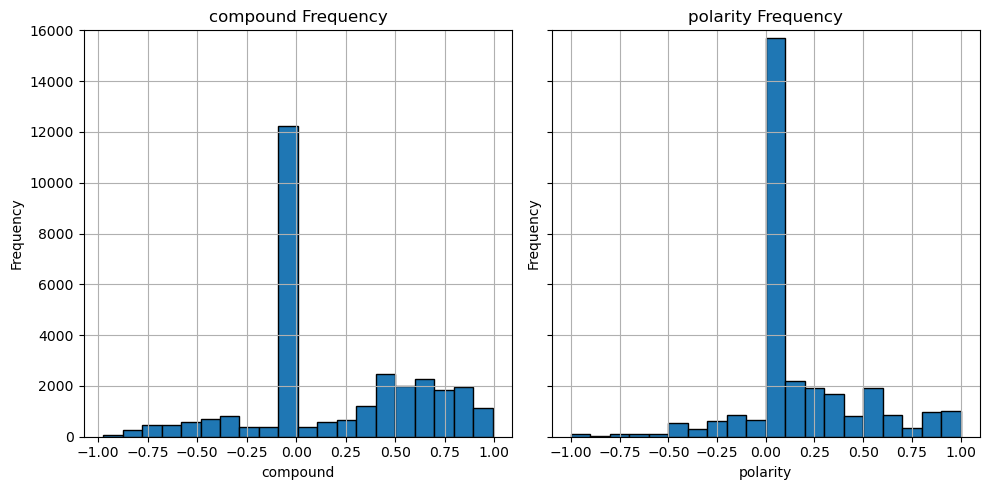

In [49]:
# Select numerical features for histograms
selected_features = ['compound', 'polarity']

# Plot histograms with consistent y-axis
fig, axes = plt.subplots(1, len(selected_features), figsize=(10, 5), sharey=True)

for ax, feature in zip(axes, selected_features):
    player_tweet_df[feature].hist(ax=ax, bins=20, edgecolor='black')
    ax.set_title(f'{feature} Frequency')
    ax.set_ylim(0, 16000)
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#### Explanation

Polarity seems to perceive the tweets as more neutral, while compound seems to perceive the tweets as more positive.

### Box Plots of Numerical Features

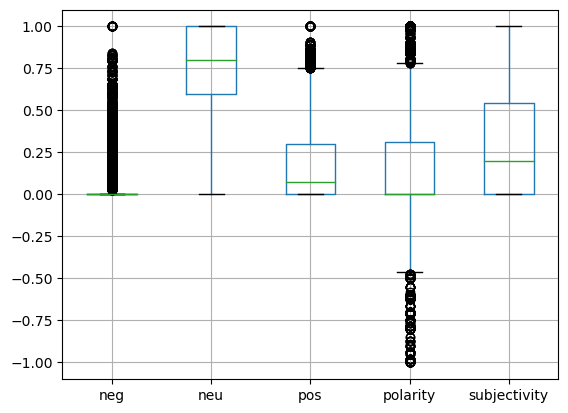

In [54]:
# Explanation: Box plots help visualize the spread and identify outliers in the data.
player_stat_tweet_df[['neg', 'neu', 'pos', 'polarity', 'subjectivity']].boxplot()
plt.show()

#### Explanation

**neg:**
- The vast majority of values are very close to 0
- There are fewer and fewer outliers as neg increases

**neu:**
- The range includes the entire 0-1 scale
- Most of the data is around 0.8 and everything else is close to that

**pos:**
- The majority of values are close to 0
- Most tweets are slightly positive

**polarity:**
- Most tweets are slightly positive but the median is 0
- There are outliers throughout the scale (probably represents a bell curve)

**subjectivity:**
- Most tweets are fairly subjective

### Scatter Matrix of Numerical Features

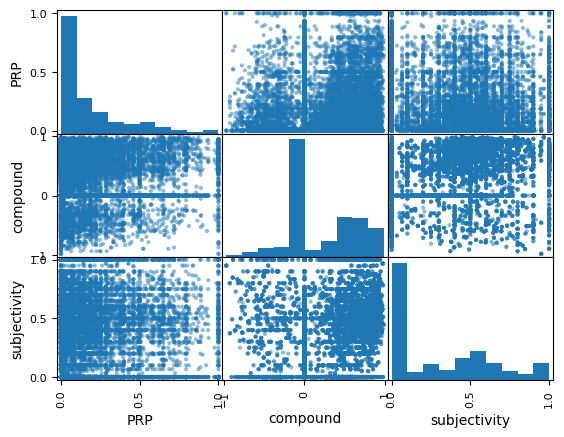

In [58]:
# Explanation: The scatter matrix displays pairwise relationships between numerical features, useful for detecting correlations.
shortened_df = player_stat_tweet_df.rename(columns={'Player_Relative_Performance': 'PRP'})
pd.plotting.scatter_matrix(shortened_df[['PRP', 'compound', 'subjectivity']])
plt.show()

#### Explanation

There seems to be general grouping in the graphs that show correlation with Relative Player Performance, which could be useful for Non-Parametric models like KNN.

## Outlier Detection and Cleaning

All the data has been cleaned and transformed to include only necessary features in the previous sections.

The outliers discussed shouldn't be removed, because they will offer different parameters and perspectives for models and could prove useful.